In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn import metrics

In [4]:
car_dataset = pd.read_csv('/content/car data.csv')
car_dataset.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [5]:
car_dataset.shape

(301, 9)

In [6]:
car_dataset.isnull().sum()

,0
Car_Name,0
Year,0
Selling_Price,0
Present_Price,0
Kms_Driven,0
Fuel_Type,0
Seller_Type,0
Transmission,0
Owner,0


In [7]:
car_dataset['Owner'].value_counts()

,count
Owner,
0,290
1,10
3,1


In [8]:
car_dataset['Transmission'].value_counts()

,count
Transmission,
Manual,261
Automatic,40


In [9]:
car_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [10]:
car_dataset['Fuel_Type'].value_counts()

,count
Fuel_Type,
Petrol,239
Diesel,60
CNG,2


In [11]:
print(car_dataset.Fuel_Type.value_counts())

Fuel_Type
Petrol    239
Diesel     60
CNG         2
Name: count, dtype: int64


##Encoding the Categorical Data

In [12]:
car_dataset.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [13]:
car_dataset['Fuel_Type'].value_counts()

,count
Fuel_Type,
Petrol,239
Diesel,60
CNG,2


In [14]:
car_dataset['Seller_Type'].value_counts()

,count
Seller_Type,
Dealer,195
Individual,106


**Fuel_Type:**

  Petrol = 0,

  Diesel = 1,

  CNG = 2

In [15]:
car_dataset.replace({'Fuel_Type':{'Petrol':0, 'Diesel':1, 'CNG':2}}, inplace=True)
car_dataset.replace({'Seller_Type':{'Dealer':0, 'Individual':1}}, inplace=True)
car_dataset.replace({'Transmission':{'Manual':0, 'Automatic':1}}, inplace=True)

/tmp/ipykernel_31702/17678478.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  car_dataset.replace({'Fuel_Type':{'Petrol':0, 'Diesel':1, 'CNG':2}}, inplace=True)
/tmp/ipykernel_31702/17678478.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  car_dataset.replace({'Seller_Type':{'Dealer':0, 'Individual':1}}, inplace=True)
/tmp/ipykernel_31702/17678478.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(cop

In [16]:
car_dataset.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,0,0,0,0
1,sx4,2013,4.75,9.54,43000,1,0,0,0
2,ciaz,2017,7.25,9.85,6900,0,0,0,0
3,wagon r,2011,2.85,4.15,5200,0,0,0,0
4,swift,2014,4.60,6.87,42450,1,0,0,0


In [17]:
car_dataset['Fuel_Type'].value_counts()

,count
Fuel_Type,
0,239
1,60
2,2


In [18]:
X = car_dataset.drop(['Car_Name','Selling_Price'], axis=1)

In [19]:
Y = car_dataset['Selling_Price']

In [20]:
print(X)

     Year  Present_Price  Kms_Driven  Fuel_Type  Seller_Type  Transmission  \
0    2014           5.59       27000          0            0             0   
1    2013           9.54       43000          1            0             0   
2    2017           9.85        6900          0            0             0   
3    2011           4.15        5200          0            0             0   
4    2014           6.87       42450          1            0             0   
..    ...            ...         ...        ...          ...           ...   
296  2016          11.60       33988          1            0             0   
297  2015           5.90       60000          0            0             0   
298  2009          11.00       87934          0            0             0   
299  2017          12.50        9000          1            0             0   
300  2016           5.90        5464          0            0             0   

     Owner  
0        0  
1        0  
2        0  
3        0 

In [21]:
print(Y)

0       3.35
1       4.75
2       7.25
3       2.85
4       4.60
       ...  
296     9.50
297     4.00
298     3.35
299    11.50
300     5.30
Name: Selling_Price, Length: 301, dtype: float64


In [22]:
X_train, X_test,Y_train, Y_test = train_test_split(X,Y, test_size=0.1, random_state=2)

In [23]:
lin_reg_model = LinearRegression()

In [24]:
lin_reg_model.fit(X_train, Y_train)

LinearRegression()

In [25]:
training_data_preditction = lin_reg_model.predict(X_train)

In [26]:
error_score = metrics.r2_score(Y_train, training_data_preditction)
print("error_score: ", error_score)

error_score:  0.8799451660493711


Visualize actual prices and predicted prices

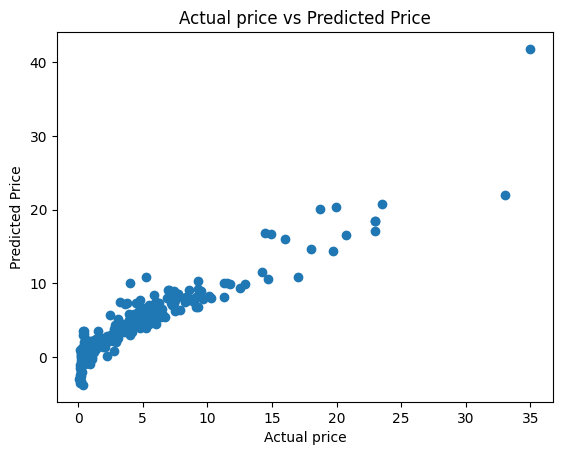

In [27]:
plt.scatter(Y_train, training_data_preditction)
plt.xlabel('Actual price')
plt.ylabel('Predicted Price')
plt.title('Actual price vs Predicted Price')
plt.show()

In [28]:
test_data_preditction = lin_reg_model.predict(X_test)
error_score = metrics.r2_score(Y_test, test_data_preditction)
print("error_score: ", error_score)

error_score:  0.8365766715027051


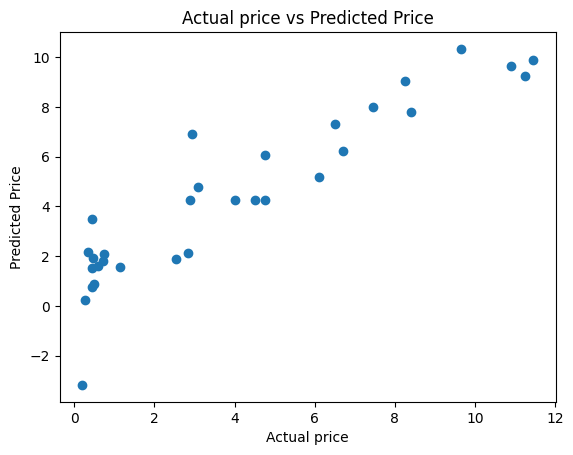

In [29]:
plt.scatter(Y_test, test_data_preditction)
plt.xlabel('Actual price')
plt.ylabel('Predicted Price')
plt.title('Actual price vs Predicted Price')
plt.show()

##2. Lasso Regression

In [30]:
lasso_reg_model = Lasso()

In [31]:
lasso_reg_model.fit(X_train, Y_train)

Lasso()

In [32]:
training_data_preditction = lasso_reg_model.predict(X_train)

In [33]:
error_score = metrics.r2_score(Y_train, training_data_preditction)
print("error_score: ", error_score)

error_score:  0.8427856123435794


Visualize actual prices and predicted prices

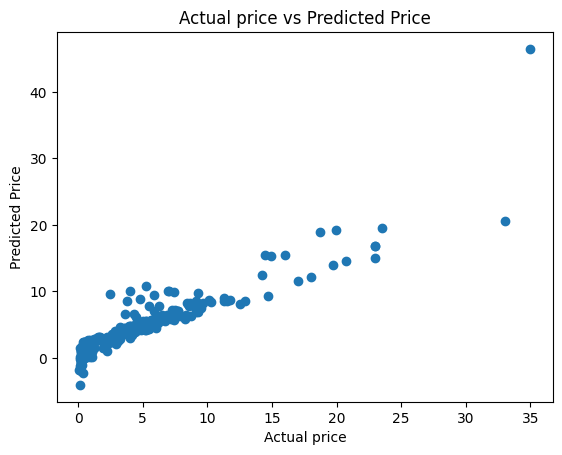

In [34]:
plt.scatter(Y_train, training_data_preditction)
plt.xlabel('Actual price')
plt.ylabel('Predicted Price')
plt.title('Actual price vs Predicted Price')
plt.show()

In [35]:
test_data_preditction = lasso_reg_model.predict(X_test)
error_score = metrics.r2_score(Y_test, test_data_preditction)
print("error_score: ", error_score)

error_score:  0.8709167941173195


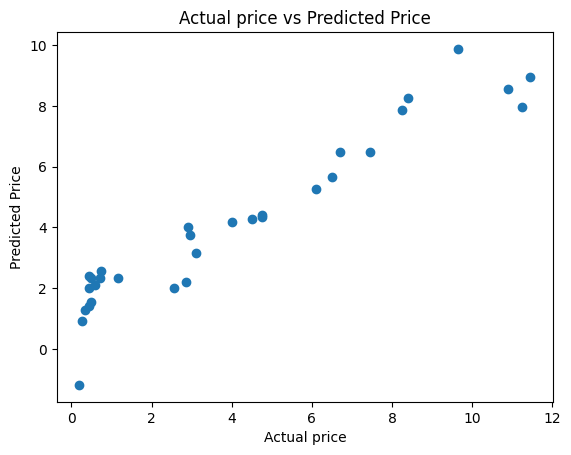

In [36]:
plt.scatter(Y_test, test_data_preditction)
plt.xlabel('Actual price')
plt.ylabel('Predicted Price')
plt.title('Actual price vs Predicted Price')
plt.show()